In [16]:
%reload_ext autoreload
%autoreload 2

import os
import pickle
import numpy as np
import healpy as hp
import json
from scipy import interpolate
from tqdm import tqdm

from fpp.utils.validation import pp_finite_sample_band
from fpp.utils.posterior import multi_corner
from fpp.models.np_model import NPModel
from numpyro.infer import MCMC, NUTS
from numpyro.infer.util import constrain_fn, unconstrain_fn

import jax.numpy as jnp
import jax
from numpyro.infer import SVI, Trace_ELBO, autoguide
import optax
from numpyro import optim

from fpp.models.np_model import NPModel

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

In [2]:
production_dir = os.environ['MYSTORE'] + f"/fermi/fermi-prob-prog/outputs/production"

i_data = 0

data = jnp.array(np.load(f"{production_dir}/simulations/fullprior-0Alm.npy")[i_data], dtype=jnp.int32)

m = NPModel(data=data)

In [ ]:
lr = 0.1
n_steps = 5000
model_static_kwargs = {'data': data}

guide = autoguide.AutoDelta(m.model)
optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(1.), optax.adam(lr)))
svi = SVI(m.model, guide, optimizer, loss=Trace_ELBO())
map_svi_results = svi.run(jax.random.PRNGKey(0), n_steps, **model_static_kwargs)
map_estimate = guide.median(map_svi_results.params)

In [25]:
lr = 0.1
n_steps = 1000
eval_every = 10
model_static_kwargs = {'data': data}
truth_dict = json.load(open(f"../outputs/truths/truths_fullprior-0Alm.json"))[i_data]

guide = autoguide.AutoDelta(m.model)
optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(1.), optax.adamw(lr)))
svi = SVI(m.model, guide, optimizer, loss=Trace_ELBO())

# Initialize SVI
svi_state = svi.init(jax.random.PRNGKey(0), **model_static_kwargs)

def compute_mean_diff(median_dict, truth_dict):
    """Mean absolute diff: each var contributes equally regardless of shape.
    For array vars, average |est - truth| elementwise, then that single
    number counts the same as a scalar var's absolute diff."""
    per_var_diffs = []
    for name, truth_val in truth_dict.items():
        if name not in median_dict:
            continue
        est = np.asarray(median_dict[name])
        truth = np.asarray(truth_val)
        abs_diff = np.abs(est - truth)
        per_var_diffs.append(np.mean(abs_diff))
    return float(np.mean(per_var_diffs))

# Run in chunks of `eval_every` so we can snapshot the guide medians
@jax.jit
def run_chunk(state):
    def body(state, _):
        state, loss = svi.update(state, **model_static_kwargs)
        return state, loss
    state, losses = jax.lax.scan(body, state, None, length=eval_every)
    return state, losses

steps_log = []
losses_log = []
mean_diff_log = []

n_chunks = n_steps // eval_every
for i in tqdm(range(n_chunks)):
    svi_state, losses = run_chunk(svi_state)
    params = svi.get_params(svi_state)
    medians = guide.median(params)
    md = compute_mean_diff(medians, truth_dict)

    step = (i + 1) * eval_every
    steps_log.append(step)
    losses_log.append(float(losses[-1]))
    mean_diff_log.append(md)

# Final params, matching what svi.run would have given you
map_svi_params = svi.get_params(svi_state)
map_estimate = guide.median(map_svi_params)

# Quick look at the trajectory
for s, l, d in zip(steps_log[::5], losses_log[::5], mean_diff_log[::5]):
    print(f"step {s:5d}  loss {l:12.3f}  mean_diff {d:.4f}")

100%|██████████| 100/100 [00:58<00:00,  1.71it/s]

step    10  loss    24009.279  mean_diff 1.5328
step    60  loss    22170.887  mean_diff 1.2770
step   110  loss    22102.450  mean_diff 0.8895
step   160  loss    22044.600  mean_diff 0.9393
step   210  loss    21986.429  mean_diff 1.0030
step   260  loss    21928.943  mean_diff 1.0611
step   310  loss    21870.618  mean_diff 1.1123
step   360  loss    21812.281  mean_diff 1.1508
step   410  loss    21768.515  mean_diff 1.1860
step   460  loss    21742.667  mean_diff 1.2081
step   510  loss    21718.572  mean_diff 1.2262
step   560  loss    21695.282  mean_diff 1.2493
step   610  loss    21671.229  mean_diff 1.2611
step   660  loss    21647.160  mean_diff 1.2828
step   710  loss    21623.878  mean_diff 1.2924
step   760  loss    21599.872  mean_diff 1.2981
step   810  loss    21575.835  mean_diff 1.3058
step   860  loss    21552.583  mean_diff 1.3125
step   910  loss    21528.586  mean_diff 1.3196
step   960  loss    21504.582  mean_diff 1.3228


Text(0, 0.5, 'mean_diff')

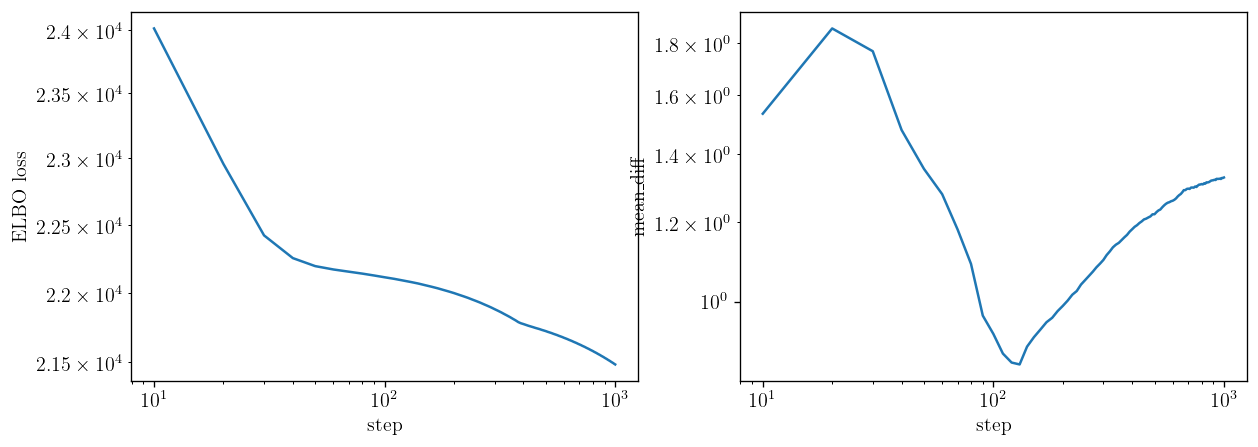

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].loglog(steps_log, losses_log)
axs[0].set_xlabel("step")
axs[0].set_ylabel("ELBO loss")
axs[1].loglog(steps_log, mean_diff_log)
axs[1].set_xlabel("step")
axs[1].set_ylabel("mean_diff")

Text(0, 0.5, 'mean_diff')

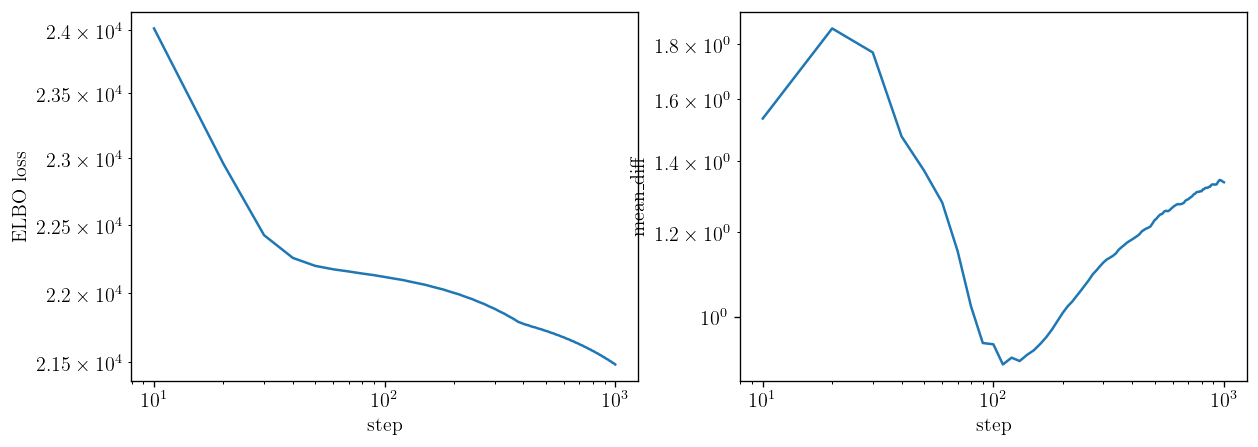

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].loglog(steps_log, losses_log)
axs[0].set_xlabel("step")
axs[0].set_ylabel("ELBO loss")
axs[1].loglog(steps_log, mean_diff_log)
axs[1].set_xlabel("step")
axs[1].set_ylabel("mean_diff")

In [23]:
for k in map_estimate:
    if map_estimate[k].shape == ():
        print(f"{k:20s}  {map_estimate[k]:.4f}  {truth_dict[k]:.4f}")

Alm_0                 -0.0487  0.0000
Alm_1                 0.0155  0.0000
Alm_2                 -0.0494  0.0000
Alm_3                 0.0157  0.0000
Alm_4                 -0.0494  0.0000
S_pib                 13.8191  13.9528
S_ics                 8.5304  10.5287
S_iso                 1.9350  0.7528
S_bub                 2.0311  1.9173
S_psc                 1.9033  2.8969
S_gce                 1.3704  0.7018
f_bulge_poiss         0.3569  0.2494
gamma_poiss           0.7847  1.1147
Sps_gce               1.6628  0.6446
f_bulge_ps            0.4288  0.4272
gamma_ps              0.6269  1.2055
Sps_dsk               2.1739  2.8962
zs                    0.2482  1.9632
C                     0.3623  2.5355
n1_gce                2.9436  5.8133
n2_gce                0.6468  0.6140
n3_gce                -7.6883  -3.7129
sb1_gce               24.7523  31.6951
lambdas_gce           0.8834  0.6682
n1_dsk                7.3551  2.2055
n2_dsk                1.5967  1.8409
n3_dsk                -1.314

In [9]:
m.get_map_estimate(data=data, rng_key=jax.random.PRNGKey(4242), lr=0.3, n_steps=5000)

100%|██████████| 5000/5000 [03:11<00:00, 26.06it/s, init loss: 28809.7498, avg. loss [4751-5000]: nan]       


{'theta_pib': Array([nan, nan, nan], dtype=float64),
 'theta_ics': Array([nan, nan, nan], dtype=float64),
 'Alm_0': Array(nan, dtype=float64),
 'Alm_1': Array(nan, dtype=float64),
 'Alm_2': Array(nan, dtype=float64),
 'Alm_3': Array(nan, dtype=float64),
 'Alm_4': Array(nan, dtype=float64),
 'S_pib': Array(nan, dtype=float64),
 'S_ics': Array(nan, dtype=float64),
 'S_iso': Array(nan, dtype=float64),
 'S_bub': Array(nan, dtype=float64),
 'S_psc': Array(nan, dtype=float64),
 'S_gce': Array(nan, dtype=float64),
 'f_bulge_poiss': Array(nan, dtype=float64),
 'theta_bulge_poiss': Array([nan, nan, nan, nan, nan], dtype=float64),
 'gamma_poiss': Array(nan, dtype=float64),
 'Sps_gce': Array(nan, dtype=float64),
 'f_bulge_ps': Array(nan, dtype=float64),
 'theta_bulge_ps': Array([nan, nan, nan, nan, nan], dtype=float64),
 'gamma_ps': Array(nan, dtype=float64),
 'Sps_dsk': Array(nan, dtype=float64),
 'zs': Array(nan, dtype=float64),
 'C': Array(nan, dtype=float64),
 'n1_gce': Array(nan, dtype=float

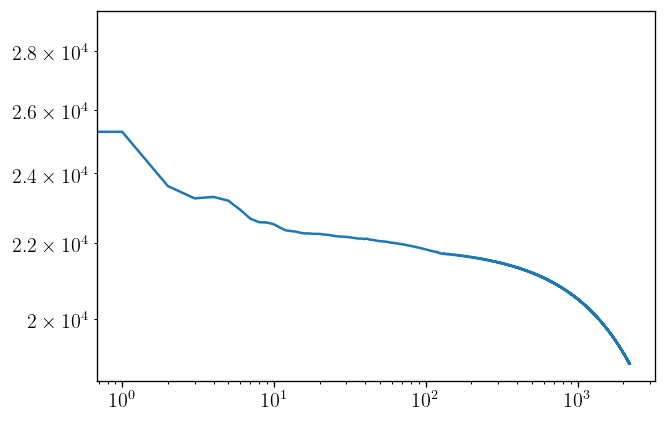

In [10]:
# ADAMW 0.3
plt.loglog(m.map_svi_results.losses)

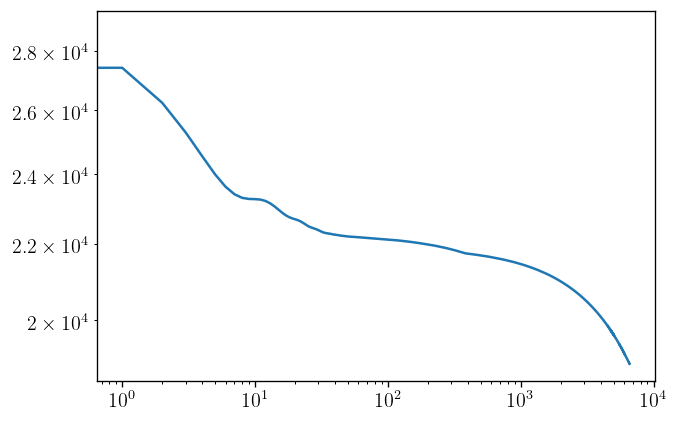

In [ ]:
# ADAMW 0.1 6000 then NAN
plt.loglog(m.map_svi_results.losses)